In [1]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos
from matplotlib.gridspec import GridSpec
import scipy.interpolate as sciint
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

In [3]:
project='realBathy'
ed='run7/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

if project=='realBathy':
    if ed == 'run2/' or ed == 'run5/' or ed == 'run7/':
        ds=xr.open_dataset(str(location) + 'theta.nc')
        dsVVEL=xr.open_dataset(str(location) + 'vvel.nc')
        dsWVEL=xr.open_dataset(str(location) + 'wvel.nc')
        dsUVEL=xr.open_dataset(str(location) + 'uvel.nc')
    else:
        for i in np.arange(10,60,10):
            var='dynDiag'+str(i)
            if i==10:
                ds=xr.open_dataset(str(location) +  str(var) + '.nc')
            else:
                ds=ds.merge(xr.open_dataset(str(location) +  str(var) + '.nc'))
else:
    var='dynDiag'
    ds=xr.open_dataset(str(location) +  str(var) + '.nc')


#varS='surfDiag'

#dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(dsG.Y)
nx=len(dsG.X) 
nz=len(dsG.Z)
nt=len(ds.T) 

umbral=ny*0.49

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']

start=np.where(ds.T/(60*60*24*360)>0.1)[0][0]
end = np.where(np.isnan(ds.THETA[:,10,10,5])==False)[0][-1]

if project=='twoBumps' or project=='2tracers':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
else:
    umbral=np.where(dsG.Depth[:-1,20].values==np.min(dsG.Depth[:-1,20].values))[0][int(len(np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0])/2)]
    umbralEnd=np.where(dsG.Depth[:,20]<np.max(dsG.Depth[:,20]))[0][-1]



if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=20
    OBend=-20
    OBx=1
    OBendx=-1

In [4]:
params = {'font.size': 15,
          'figure.figsize': (20, 20),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

In [4]:
t=0
space=6
dep=0
VARS=list(ds.keys())[2:]

divT=(60*60*24*360)
unit= 'Years'
tsteps=np.arange(0,len(ds.T[:end]),len(ds.T[:end])/10)

#for variable in VARS:

variable=VARS[0]

exec(f'varin=ds.{variable}')
title= varin.description 
if variable == 'VVEL' :
    Yin=dsG.Yp1
else:
    Yin=dsG.Y
if variable == 'UVEL' :
    Xin=dsG.Xp1[OBx:OBendx]
else:
    Xin=dsG.X[OBx:OBendx]

if variable == 'THETA':
    vmin=10
    vmax=15
    cmapi=cmocean.cm.thermal
elif variable == 'PHIHYD':
    vmin=np.min(varin[3].values)
    vmax=-np.min(varin[3].values)
    cmapi=cmocean.cm.delta
elif variable == 'WVEL': 
    vmin=np.min(varin.values)
    vmax=-np.min(varin.values)
    cmapi=cmocean.cm.balance
else: 
    vmin=np.min(varin)
    vmax=-np.min(varin)
    cmapi=cmocean.cm.balance

levels=np.linspace(vmin,vmax,15)

fig,ax=plt.subplots(2,5)

for i in range(10):
    tin=int(tsteps[i])
    if i<=4:
        axin=ax[0,i]
        axin.xaxis.set_tick_params(labelbottom=False)
    elif np.logical_and(i>4,i<=9):
        axin=ax[1,i-5]
        axin.set(xlabel='Distance in x [km]')
    if i==0 or i==10 or i==5 :
        axin.set(ylabel='Distance in y [km]')
    else: 
        axin.yaxis.set_tick_params(labelleft=False)


    timein=ds.T[tin]/(60*60*24)
    cax0=axin.pcolormesh(Xin/1000, Yin/1000, varin[tin,dep,:,OBx:OBendx],vmin=vmin,vmax=vmax,cmap=cmapi)
    axin.set(title=f'Year {timein/360:.1f} at {dsG.Z[dep]:.1f} m depth')


    gridY,gridX=np.meshgrid(Yin[1:-1].values,Xin[OBx:OBendx].values)

    interpV=sciint.RegularGridInterpolator((dsG.Yp1.values,dsG.X.values),ds.VVEL[tin,dep,:,:].values)
    V=interpV((gridY,gridX))

    interpU=sciint.RegularGridInterpolator((dsG.Y.values,dsG.Xp1.values),ds.UVEL[tin,dep,:,:].values)
    U=interpU((gridY,gridX))

    axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])

    if project =='OpenNorth':
        axin.axhline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
        axin.text( 0.05, 0.09,'End of \nSponge', color='white', 
            transform=axin.transAxes,fontsize=8)
        axin.axhline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
        axin.text( 0.05,0.82, 'End of \nSponge', color='white', 
            transform=axin.transAxes,fontsize=8)
    else:
        axin.axhline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
        axin.text( 0.05, 0.09, 'End of \nSponge', color='white', 
            transform=axin.transAxes,fontsize=8)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(cax0, cax=cbar_ax)
cbar_ax.set_ylabel(title)

fig.tight_layout()

fig.patch.set_alpha(0.0)
#plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ '10Years' + str(variable) +  str(dep) + 'm.png', bbox_inches='tight')

IndexError: list index out of range

# Three different depths

In [5]:
def BottomConc(vel, hfac, nz,nt, ny,nx,loc):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((nt,ny,nx))
    BottomInd = np.argmax(hfac[::-1,:,5]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-loc # Get index of unreversed z axis
    
    for j in range(nt):
        for i in range(ny): 
            for k in range(nx): 
                BotVel[j,i,k] = vel[j,int(BottomInd[i]),i,k] 
                
    
    return (BotVel,BottomInd.astype(int))


In [6]:
nz=len(dsG.Z)
ny=len(dsG.Y)
nt=len(ds.T)
nx=len(dsG.X)

tempOut,BottomInd=BottomConc(ds.THETA[:,:,:,:],hFacC[:,:,:].values , nz, nt, ny,nx,1)

In [7]:
vvelOut,BottomInd=BottomConc(dsVVEL.VVEL[:,:,:,:],hFacS[:,:,:].values , nz, nt, ny+1,nx,1)

In [8]:
uvelOut,BottomInd=BottomConc(dsUVEL.UVEL[:,:,:,:],hFacW[:,:,:].values , nz, nt, ny,nx+1,1)

In [ ]:
#wvelOut,BottomInd=BottomConc(dsWVEL.WVEL[:,:,:,:],hFacC[:,:,:].values , nz, nt, ny,nx,1)

In [9]:
umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
umbral2=np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==np.min(dsG.Depth[int(ny/2):-int(ny/4),20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==600)[0])/2)]+int(ny/2)+1
umbral3=np.where(dsG.Depth[-int(ny/4):,20].values==np.min(dsG.Depth[-int(ny/4):,20].values))[0][0]+(len(dsG.Depth[:,0])-int(ny/4))-10


In [9]:
params = {'font.size': 15,
          'figure.figsize': (10, 7),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

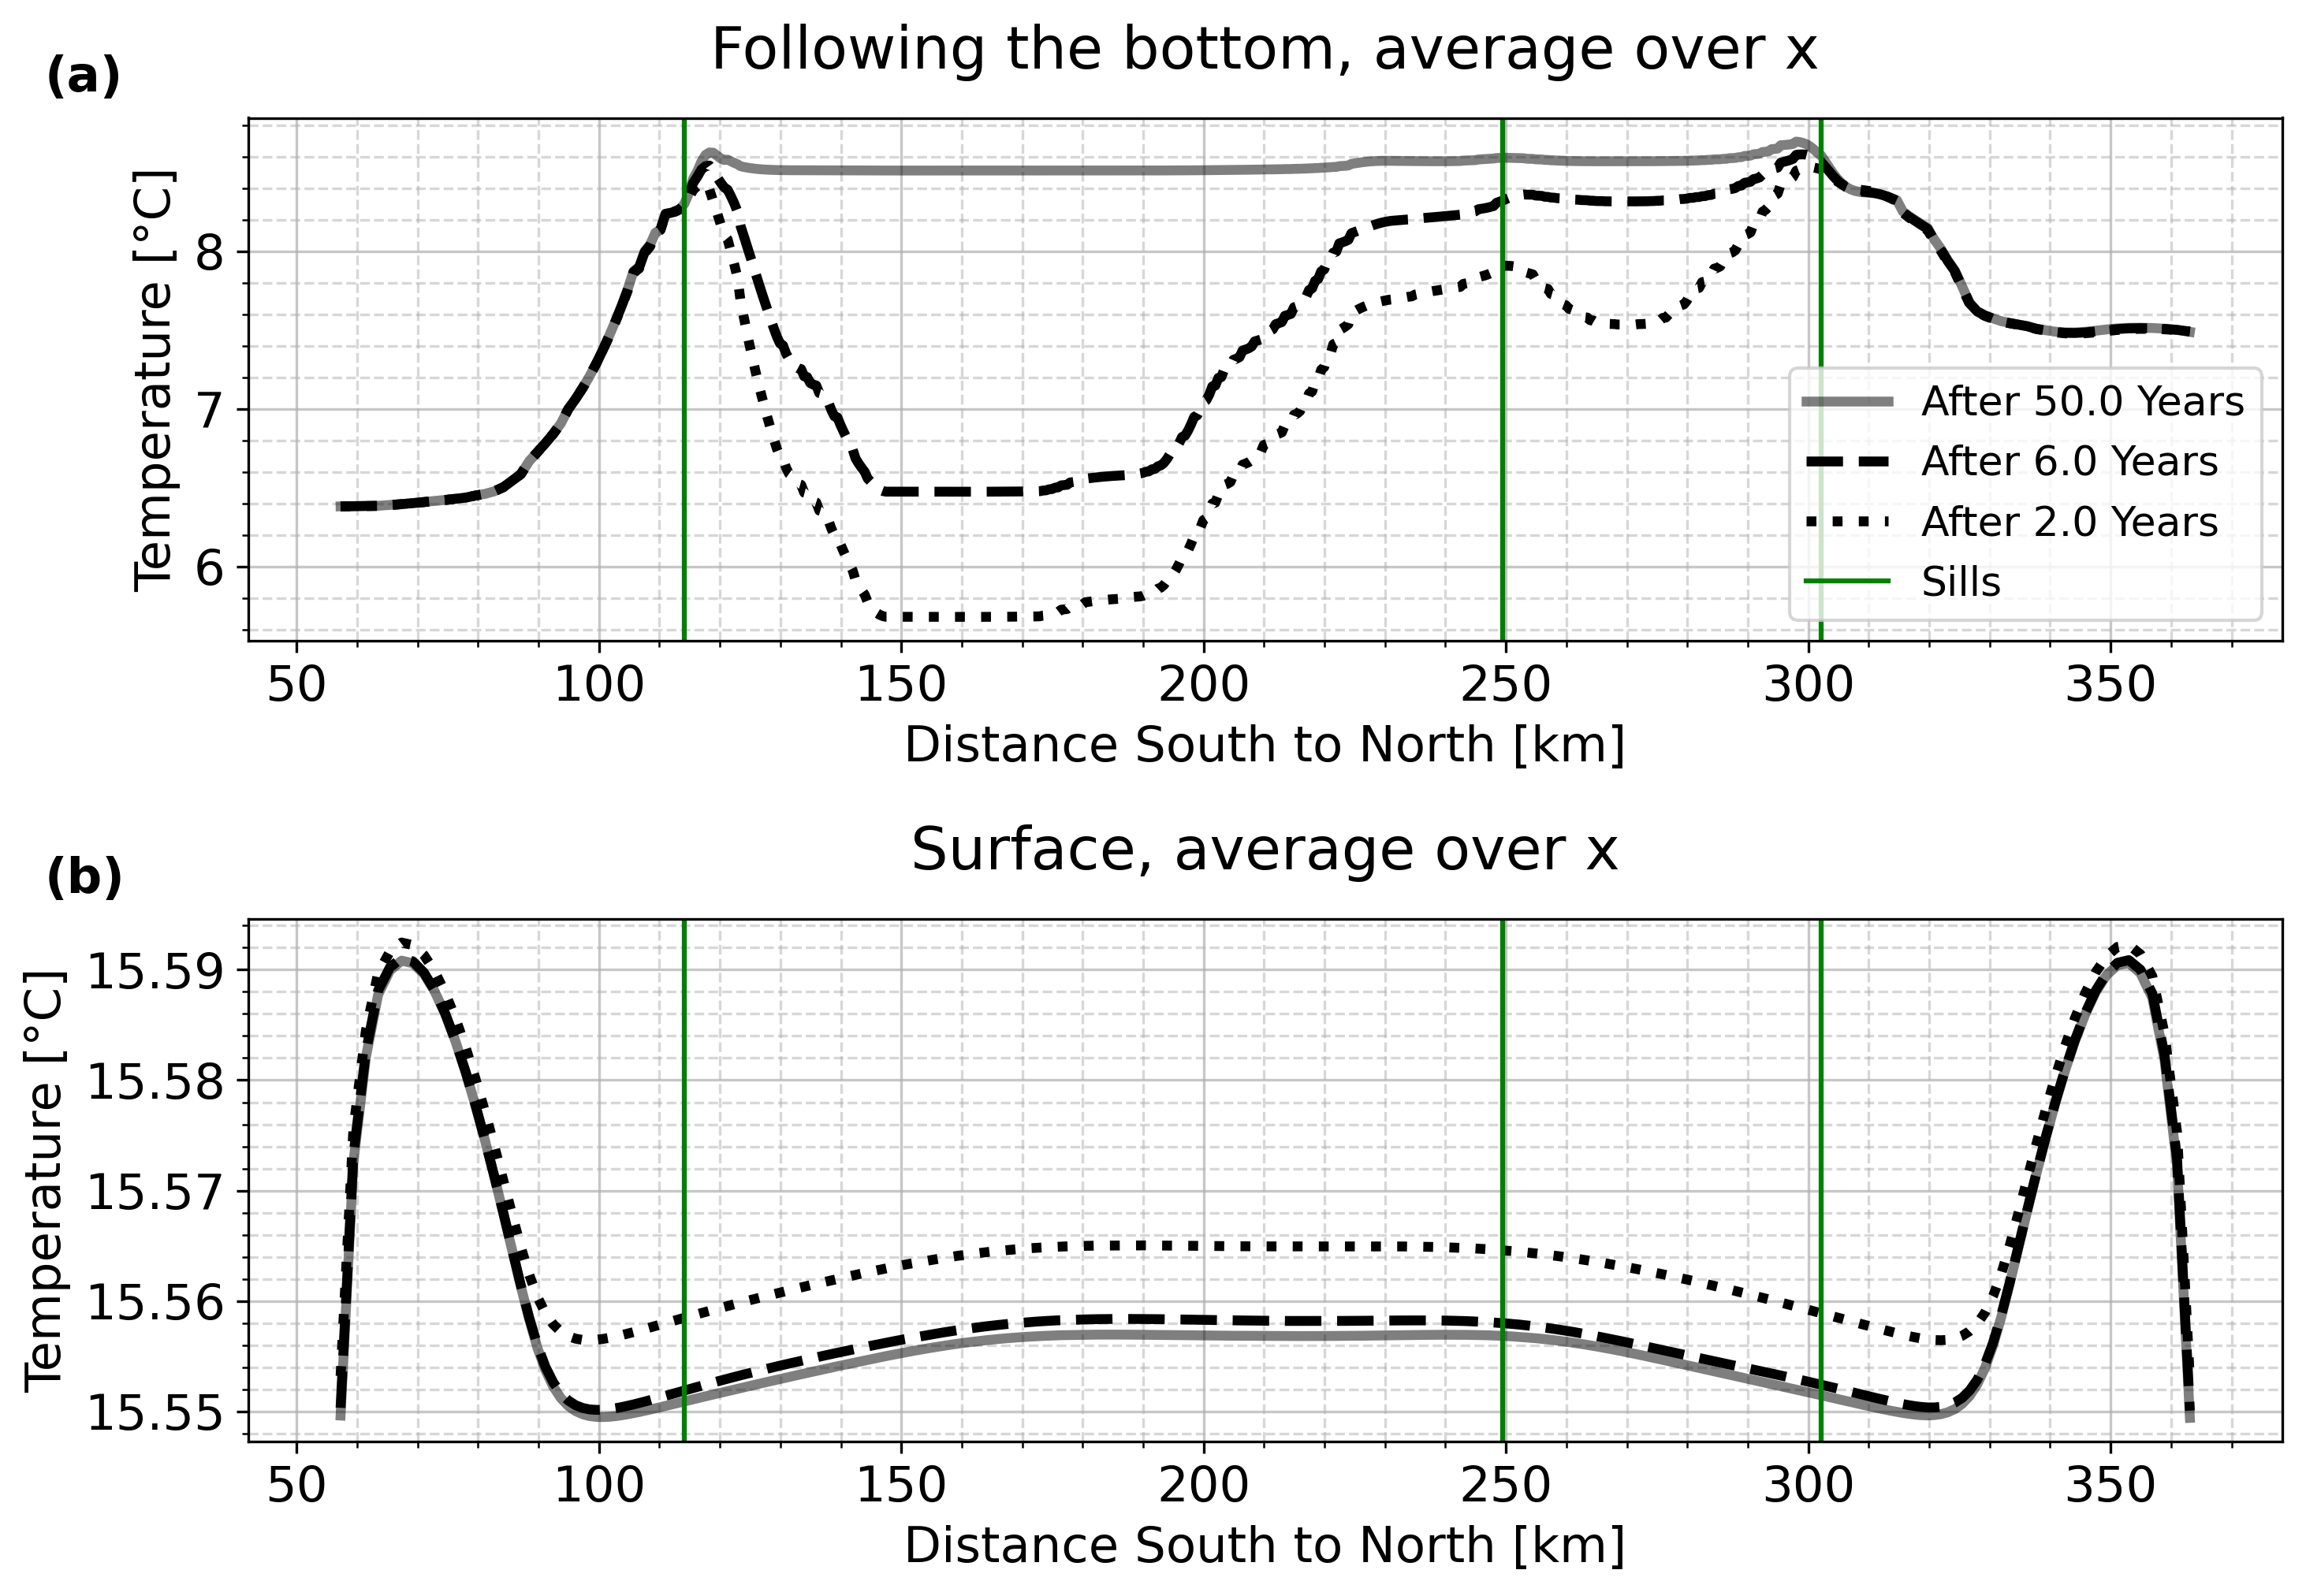

In [10]:
indZ=-1
tinStartW=3
tinMidW=11 #int(len(ds.T)/2+1)
tinEndW=-1

tinStartC=2
tinMidC=10 #int(len(ds.T)/2)
tinEndC=-2

fig,axin=plt.subplots(2)

tempSurf= np.mean(tempOut[tinEndW,OB:OBend,OBx:OBendx],axis=1)
tempSurf2= np.mean(tempOut[tinMidW,OB:OBend,OBx:OBendx],axis=1)
tempSurf3= np.mean(tempOut[tinStartW,OB:OBend,OBx:OBendx],axis=1)

ax=axin[0]
ax.plot(dsG.Y[OB:OBend].values/1000,tempSurf,linewidth=3,color='k',label=f'After {ds.T[tinEndW].values/(3600*24*360)} Years',alpha=0.5)
ax.plot(dsG.Y[OB:OBend].values/1000,tempSurf2,linewidth=3,color='k',linestyle='dashed',label=f'After {ds.T[tinMidW].values/(3600*24*360)} Years')
ax.plot(dsG.Y[OB:OBend].values/1000,tempSurf3,linewidth=3,color='k',linestyle='dotted',label=f'After {ds.T[tinStartW].values/(3600*24*360)} Years')

ax.axvline(dsG.Y[umbral1].values/1000,color='green')
ax.axvline(dsG.Y[umbral2].values/1000,color='green')
ax.axvline(dsG.Y[umbral3].values/1000,color='green',label='Sills')

ax.set(xlabel='Distance South to North [km]',ylabel='Temperature [°C]')
ax.set_title('Following the bottom, average over x',pad=15)

ax.minorticks_on()

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)
ax.text(-0.1, 1.05, '(a)', fontweight='bold', color='k', 
        transform=ax.transAxes)
ax.legend(fontsize='small')
ax=axin[1]
indZ=0
tempSurf= np.mean(np.ma.masked_array(np.mean(ds.THETA[-2:,indZ,OB:OBend,OBx:OBendx],axis=0),mask=mask[indZ,OB:OBend,OBx:OBendx]),axis=1)
tempSurf2= np.mean(np.ma.masked_array(np.mean(ds.THETA[10:12,indZ,OB:OBend,OBx:OBendx],axis=0),mask=mask[indZ,OB:OBend,OBx:OBendx]),axis=1)
tempSurf3= np.mean(np.ma.masked_array(np.mean(ds.THETA[2:4,indZ,OB:OBend,OBx:OBendx],axis=0),mask=mask[indZ,OB:OBend,OBx:OBendx]),axis=1)
locmax=np.argmax(tempSurf3)+OB

ax.plot(dsG.Y[OB:OBend].values/1000,tempSurf,linewidth=3,color='k',label=f'After {ds.T[-1].values/(3600*24*360)} Years',alpha=0.5)
ax.plot(dsG.Y[OB:OBend].values/1000,tempSurf2,linewidth=3,color='k',linestyle='dashed',label=f'After {ds.T[11].values/(3600*24*360)} Years')
ax.plot(dsG.Y[OB:OBend].values/1000,tempSurf3,linewidth=3,color='k',linestyle='dotted',label=f'After {ds.T[3].values/(3600*24*360)} Years')

ax.axvline(dsG.Y[umbral1].values/1000,color='green')
ax.axvline(dsG.Y[umbral2].values/1000,color='green')
ax.axvline(dsG.Y[umbral3].values/1000,color='green')

ax.set(xlabel='Distance South to North [km]',ylabel='Temperature [°C]')
ax.set_title('Surface, average over x',pad=15)

ax.minorticks_on()

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)
ax.text(-0.1, 1.05, '(b)', fontweight='bold', color='k', 
        transform=ax.transAxes)
#ax.legend(fontsize='small')

fig.tight_layout()
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'TemperatureBottom.png', bbox_inches='tight')

In [14]:
params = {'font.size': 15,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_75008/2603274725.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


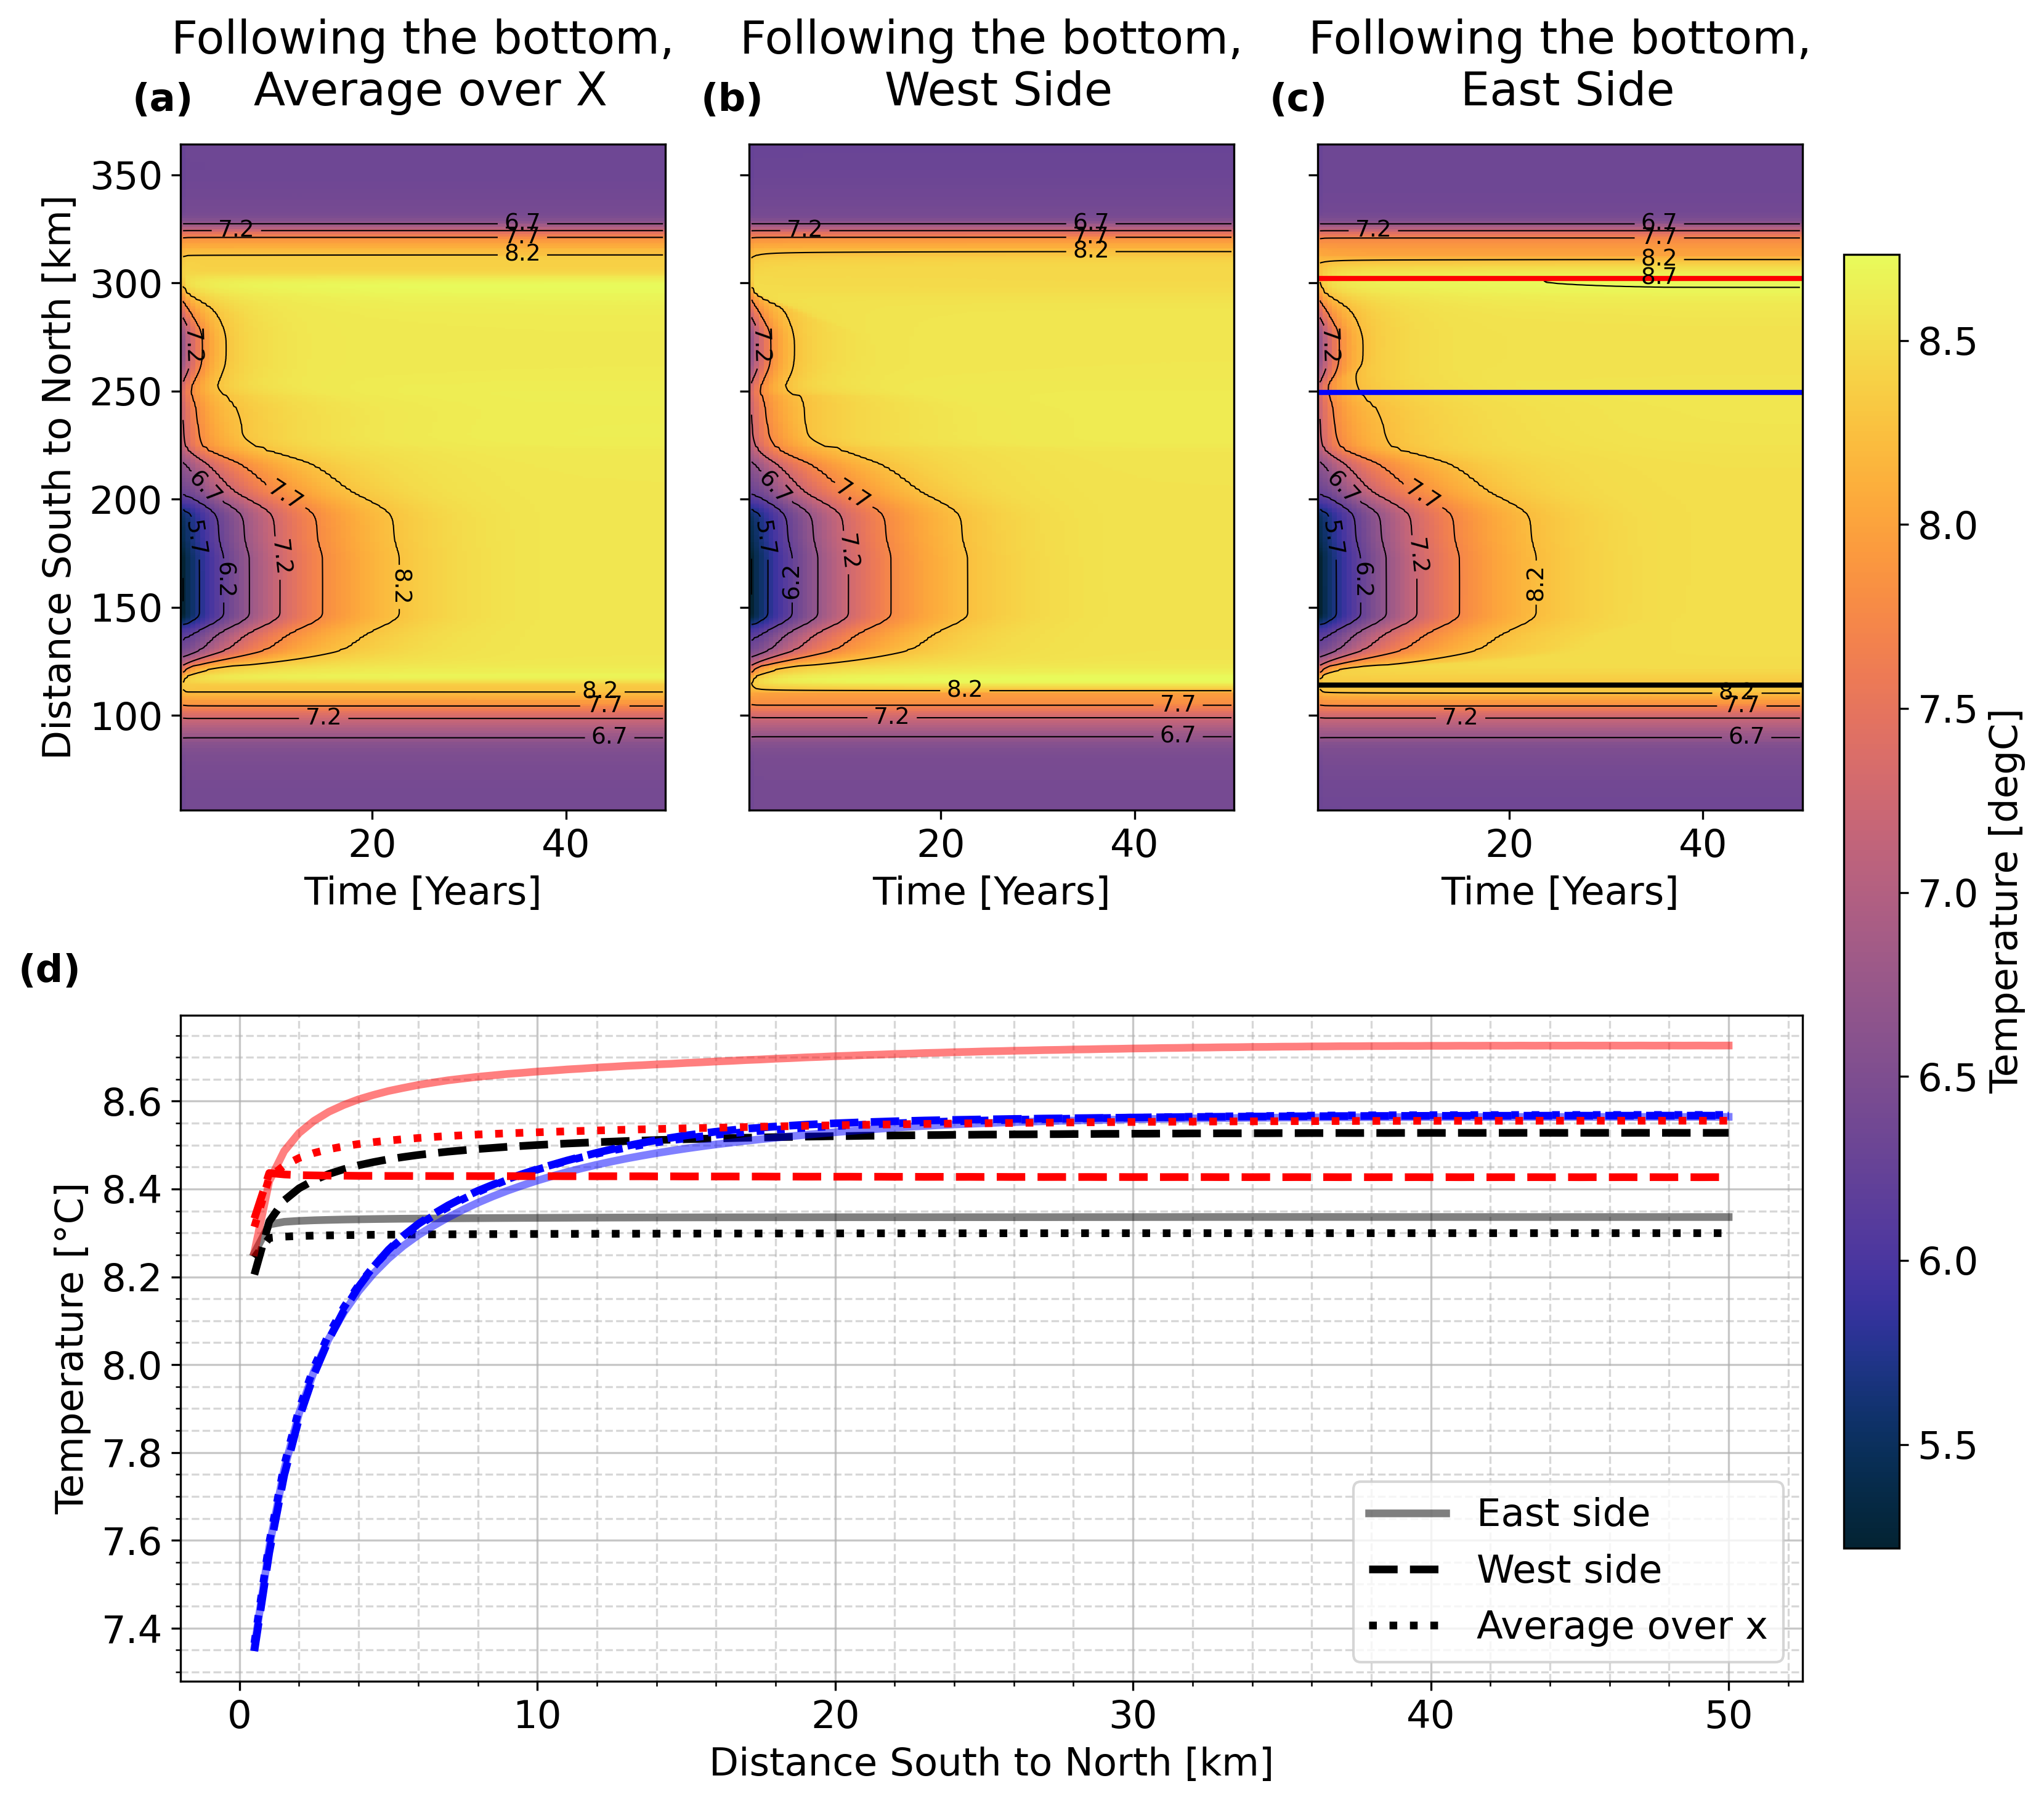

In [15]:
indZ=-1

vmin=np.min(tempOut[:,OB:OBend,OBendx-1].T) #np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
vmax=np.max(tempOut[:,OB:OBend,OBendx-1].T) #-np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
levels=np.arange(vmin,vmax,0.5)

fig = plt.figure()
gs = GridSpec(nrows=2, ncols=3)
ax = fig.add_subplot(gs[0, 0])

cax=ax.pcolormesh(ds.T.values/(3600*360*24),dsG.Y[OB:OBend].values/1000,np.mean(tempOut[:,OB:OBend,OBx:OBendx],axis=2).T,cmap=cmocean.cm.thermal)
caxC=ax.contour(ds.T.values/(3600*360*24),dsG.Y[OB:OBend].values/1000,np.mean(tempOut[:,OB:OBend,OBx:OBendx],axis=2).T,levels=levels,colors='k',linewidths=0.5)
ax.clabel(caxC, inline=1, fmt='%1.1f',fontsize=9)


ax.set(xlabel='Time [Years]',ylabel='Distance South to North [km]')
ax.set_title('Following the bottom,\n Average over X', pad=15)

ax.text(-0.1, 1.05, '(a)', fontweight='bold', color='k', 
        transform=ax.transAxes)
ax = fig.add_subplot(gs[0, 1])
cax=ax.pcolormesh(ds.T.values/(3600*360*24),dsG.Y[OB:OBend].values/1000,tempOut[:,OB:OBend,OBx].T,cmap=cmocean.cm.thermal)
caxC=ax.contour(ds.T.values/(3600*360*24),dsG.Y[OB:OBend].values/1000,tempOut[:,OB:OBend,OBx].T,levels=levels,colors='k',linewidths=0.5)
ax.clabel(caxC, inline=1, fmt='%1.1f',fontsize=9)

ax.tick_params(axis='y', which='both', left=True, right=False, labelleft=False) 
ax.set(xlabel='Time [Years]')
ax.set_title('Following the bottom,\n West Side', pad=15)

ax.text(-0.1, 1.05, '(b)', fontweight='bold', color='k', 
        transform=ax.transAxes)

ax = fig.add_subplot(gs[0, 2])
cax=ax.pcolormesh(ds.T.values/(3600*360*24),dsG.Y[OB:OBend].values/1000,tempOut[:,OB:OBend,OBendx-1].T,cmap=cmocean.cm.thermal)
caxC=ax.contour(ds.T.values/(3600*360*24),dsG.Y[OB:OBend].values/1000,tempOut[:,OB:OBend,OBendx-1].T,levels=levels,colors='k',linewidths=0.5)
ax.clabel(caxC, inline=1, fmt='%1.1f',fontsize=9)

ax.tick_params(axis='y', which='both', left=True, right=False, labelleft=False) 
ax.set(xlabel='Time [Years]')
ax.set_title('Following the bottom,\n East Side', pad=15)

ax.text(-0.1, 1.05, '(c)', fontweight='bold', color='k', 
        transform=ax.transAxes)
cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(cax, cax=cbar_ax)
cbar_ax.set_ylabel('Temperature [degC]')

ax.axhline(dsG.Y[umbral1].values/1000,color='black',linewidth=2)
ax.axhline(dsG.Y[umbral2].values/1000,color='blue',linewidth=2)
ax.axhline(dsG.Y[umbral3].values/1000,color='red',linewidth=2)

ax = fig.add_subplot(gs[1, :])
ax.plot(ds.T.values/(3600*360*24),tempOut[:,umbral1,OBendx-1],linewidth=3,color='k',label=f'East side',alpha=0.5)
ax.plot(ds.T.values/(3600*360*24),tempOut[:,umbral1,OBx],linewidth=3,color='k',linestyle='dashed',label=f'West side')
ax.plot(ds.T.values/(3600*360*24),np.mean(tempOut[:,umbral1,OBx:OBendx],axis=1),linewidth=3,color='k',linestyle='dotted',label=f'Average over x',)

ax.plot(ds.T.values/(3600*360*24),tempOut[:,umbral2,OBendx-1],linewidth=3,color='blue',alpha=0.5)
ax.plot(ds.T.values/(3600*360*24),tempOut[:,umbral2,OBx],linewidth=3,color='blue',linestyle='dashed')
ax.plot(ds.T.values/(3600*360*24),np.mean(tempOut[:,umbral2,OBx:OBendx],axis=1),linewidth=3,color='blue',linestyle='dotted')

ax.plot(ds.T.values/(3600*360*24),tempOut[:,umbral3,OBendx-1],linewidth=3,color='red',alpha=0.5)
ax.plot(ds.T.values/(3600*360*24),tempOut[:,umbral3,OBx],linewidth=3,color='red',linestyle='dashed')
ax.plot(ds.T.values/(3600*360*24),np.mean(tempOut[:,umbral3,OBx:OBendx],axis=1),linewidth=3,color='red',linestyle='dotted')


ax.legend()
ax.set(xlabel='Distance South to North [km]',ylabel='Temperature [°C]')
#ax.set_ylim((8.5,8.8))
ax.minorticks_on()

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)
ax.text(-0.1, 1.05, '(d)', fontweight='bold', color='k', 
        transform=ax.transAxes)

fig.tight_layout()

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'BotTime.png', bbox_inches='tight')

In [23]:
params = {'font.size': 10,
          'figure.figsize': (12, 8),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [25]:
start=np.where(ds.T/(60*60*24*360)>1)[0][0]
start1=np.where(ds.T/(60*60*24*360)<2)[0][-1]
umby=int(ny*0.4)
closE=np.where(dsG.Y>=130000)[0][0]

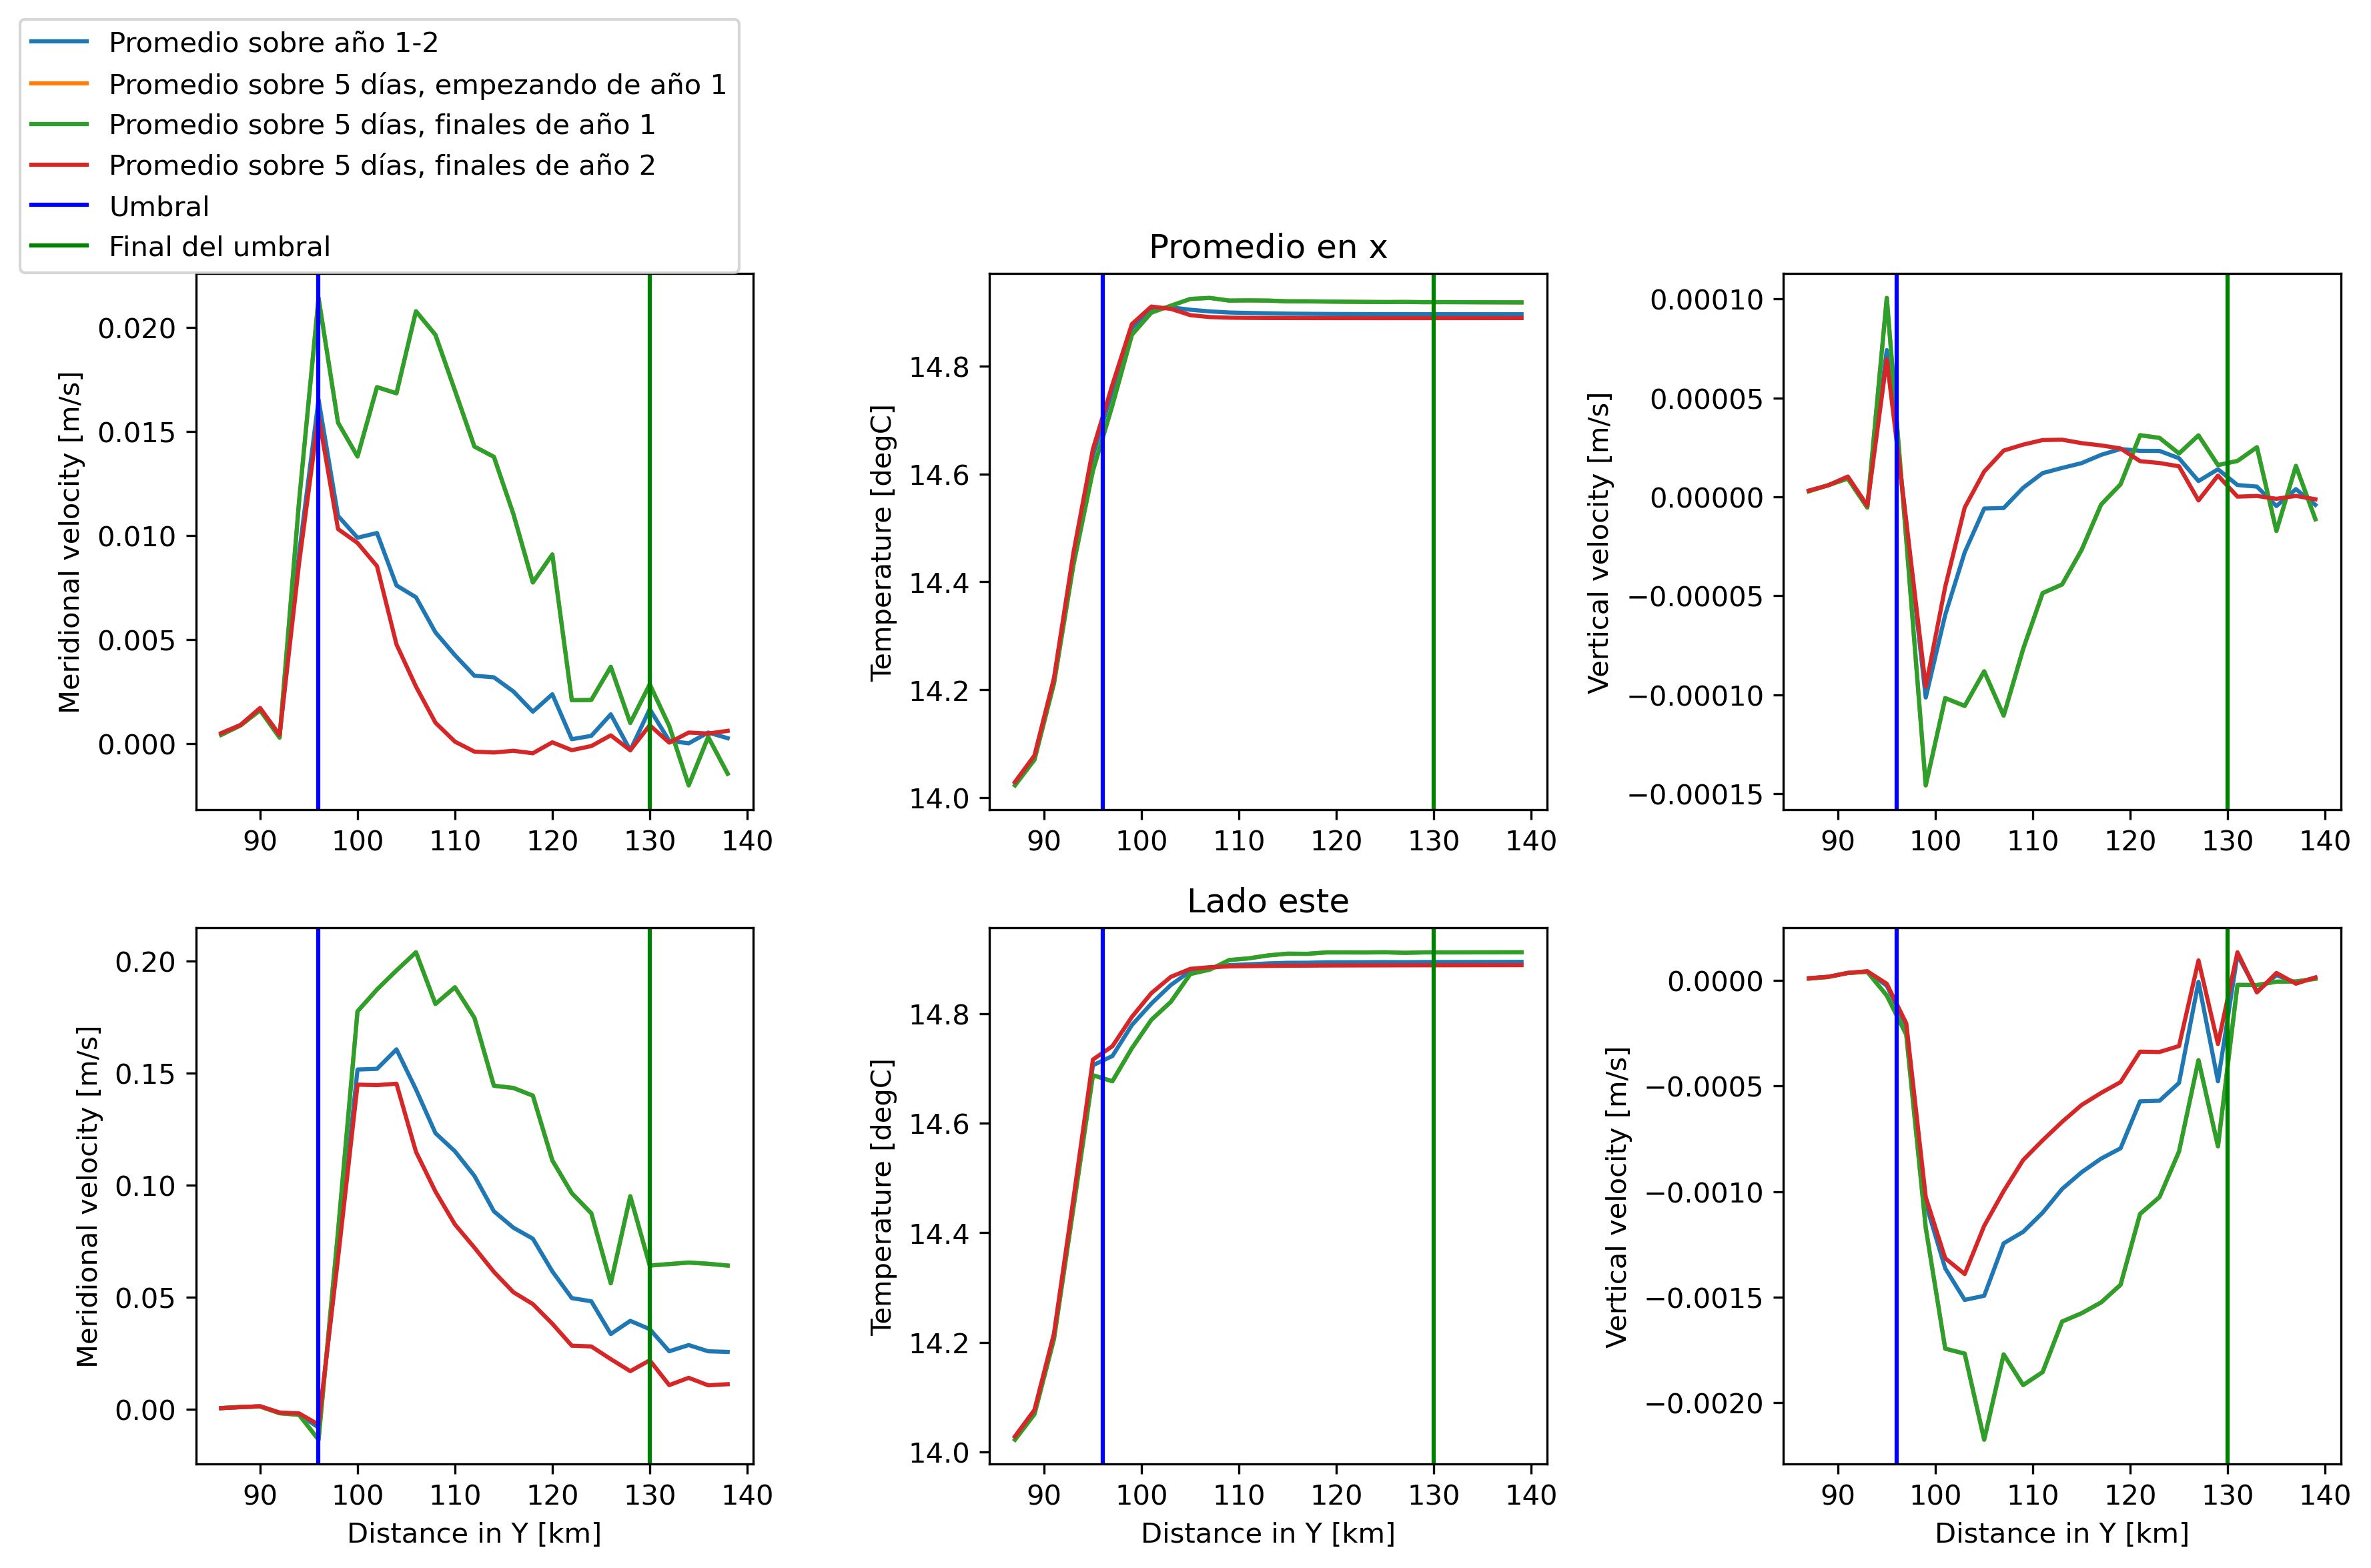

In [26]:
fig,axin=plt.subplots(2,3)
ax=axin[0,0]
ax.plot(dsG.Yp1[umby-5:closE+5]/1000,np.mean(vvelOut[start:,umby-5:closE+5,1:-2],axis=0),axis=1),label='Promedio sobre año 1-2')
ax.plot(dsG.Yp1[umby-5:closE+5]/1000,np.mean(vvelOut[start,umby-5:closE+5,1:-2],axis=1),label='Promedio sobre 5 días, empezando de año 1')
ax.plot(dsG.Yp1[umby-5:closE+5]/1000,np.mean(vvelOut[start1,umby-5:closE+5,1:-2],axis=1),label='Promedio sobre 5 días, finales de año 1')
ax.plot(dsG.Yp1[umby-5:closE+5]/1000,np.mean(vvelOut[-1,umby-5:closE+5,1:-2],axis=1),label='Promedio sobre 5 días, finales de año 2')

ax.set(ylabel='Meridional velocity [m/s]')
ax.axvline(dsG.Yp1[umby]/1000,color='blue',label='Umbral')
ax.axvline(dsG.Yp1[closE]/1000,color='green', label='Final del umbral')

ax1=axin[0,1]
ax1.plot(dsG.Y[umby-5:closE+5]/1000,np.mean(np.mean(tempOut[start:,umby-5:closE+5,1:-2],axis=0),axis=1),label='Promedio sobre año 1-2')
ax1.plot(dsG.Y[umby-5:closE+5]/1000,np.mean(tempOut[start,umby-5:closE+5,1:-2],axis=1),label='Promedio sobre 5 días, empezando de año 1')
ax1.plot(dsG.Y[umby-5:closE+5]/1000,np.mean(tempOut[start1,umby-5:closE+5,1:-2],axis=1),label='Promedio sobre 5 días, finales de año 1')
ax1.plot(dsG.Y[umby-5:closE+5]/1000,np.mean(tempOut[-1,umby-5:closE+5,1:-2],axis=1),label='Promedio sobre 5 días, finales de año 2')

ax1.set(ylabel='Temperature [degC]',title='Promedio en x')
ax1.axvline(dsG.Yp1[umby]/1000,color='blue',label='Umbral')
ax1.axvline(dsG.Yp1[closE]/1000,color='green', label='Final del umbral')

ax2=axin[0,2]
ax2.plot(dsG.Y[umby-5:closE+5]/1000,np.mean(np.mean(wvelOut[start:,umby-5:closE+5,1:-2],axis=0),axis=1),label='Promedio sobre año 1-2')
ax2.plot(dsG.Y[umby-5:closE+5]/1000,np.mean(wvelOut[start,umby-5:closE+5,1:-2],axis=1),label='Promedio sobre 5 días, empezando de año 1')
ax2.plot(dsG.Y[umby-5:closE+5]/1000,np.mean(wvelOut[start1,umby-5:closE+5,1:-2],axis=1),label='Promedio sobre 5 días, finales de año 1')
ax2.plot(dsG.Y[umby-5:closE+5]/1000,np.mean(wvelOut[-1,umby-5:closE+5,1:-2],axis=1),label='Promedio sobre 5 días, finales de año 2')

ax2.set(ylabel='Vertical velocity [m/s]')

ax2.axvline(dsG.Yp1[umby]/1000,color='blue',label='Umbral')
ax2.axvline(dsG.Yp1[closE]/1000,color='green', label='Final del umbral')

ax.legend(bbox_to_anchor=[1, 1.5])

ax=axin[1,0]
ax.plot(dsG.Yp1[umby-5:closE+5]/1000,np.mean(vvelOut[start:,umby-5:closE+5,-2],axis=0),label='Promedio sobre año 1-2')
ax.plot(dsG.Yp1[umby-5:closE+5]/1000,vvelOut[start,umby-5:closE+5,-2],label='Promedio sobre 5 días, empezando de año 1')
ax.plot(dsG.Yp1[umby-5:closE+5]/1000,vvelOut[start1,umby-5:closE+5,-2],label='Promedio sobre 5 días, finales de año 1')
ax.plot(dsG.Yp1[umby-5:closE+5]/1000,vvelOut[-1,umby-5:closE+5,-2],label='Promedio sobre 5 días, finales de año 2')

ax.set(ylabel='Meridional velocity [m/s]',xlabel='Distance in Y [km]')
ax.axvline(dsG.Yp1[umby]/1000,color='blue',label='Umbral')
ax.axvline(dsG.Yp1[closE]/1000,color='green', label='Final del umbral')

ax1=axin[1,1]
ax1.plot(dsG.Y[umby-5:closE+5]/1000,np.mean(tempOut[start:,umby-5:closE+5,-2],axis=0),label='Promedio sobre año 1-2')
ax1.plot(dsG.Y[umby-5:closE+5]/1000,tempOut[start,umby-5:closE+5,-2],label='Promedio sobre 5 días, empezando de año 1')
ax1.plot(dsG.Y[umby-5:closE+5]/1000,tempOut[start1,umby-5:closE+5,-2],label='Promedio sobre 5 días, finales de año 1')
ax1.plot(dsG.Y[umby-5:closE+5]/1000,tempOut[-1,umby-5:closE+5,-2],label='Promedio sobre 5 días, finales de año 2')

ax1.set(ylabel='Temperature [degC]',title='Lado este',xlabel='Distance in Y [km]')
ax1.axvline(dsG.Yp1[umby]/1000,color='blue',label='Umbral')
ax1.axvline(dsG.Yp1[closE]/1000,color='green', label='Final del umbral')

ax2=axin[1,2]
ax2.plot(dsG.Y[umby-5:closE+5]/1000,np.mean(wvelOut[start:,umby-5:closE+5,-2],axis=0),label='Promedio sobre año 1-2')
ax2.plot(dsG.Y[umby-5:closE+5]/1000,wvelOut[start,umby-5:closE+5,-2],label='Promedio sobre 5 días, empezando de año 1')
ax2.plot(dsG.Y[umby-5:closE+5]/1000,wvelOut[start1,umby-5:closE+5,-2],label='Promedio sobre 5 días, finales de año 1')
ax2.plot(dsG.Y[umby-5:closE+5]/1000,wvelOut[-1,umby-5:closE+5,-2],label='Promedio sobre 5 días, finales de año 2')

ax2.set(ylabel='Vertical velocity [m/s]',xlabel='Distance in Y [km]')

ax2.axvline(dsG.Yp1[umby]/1000,color='blue',label='Umbral')
ax2.axvline(dsG.Yp1[closE]/1000,color='green', label='Final del umbral')


fig.tight_layout()

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'LinesBottomVals.png', bbox_inches='tight')

In [27]:
params = {'font.size': 15,
          'figure.figsize': (20, 15),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

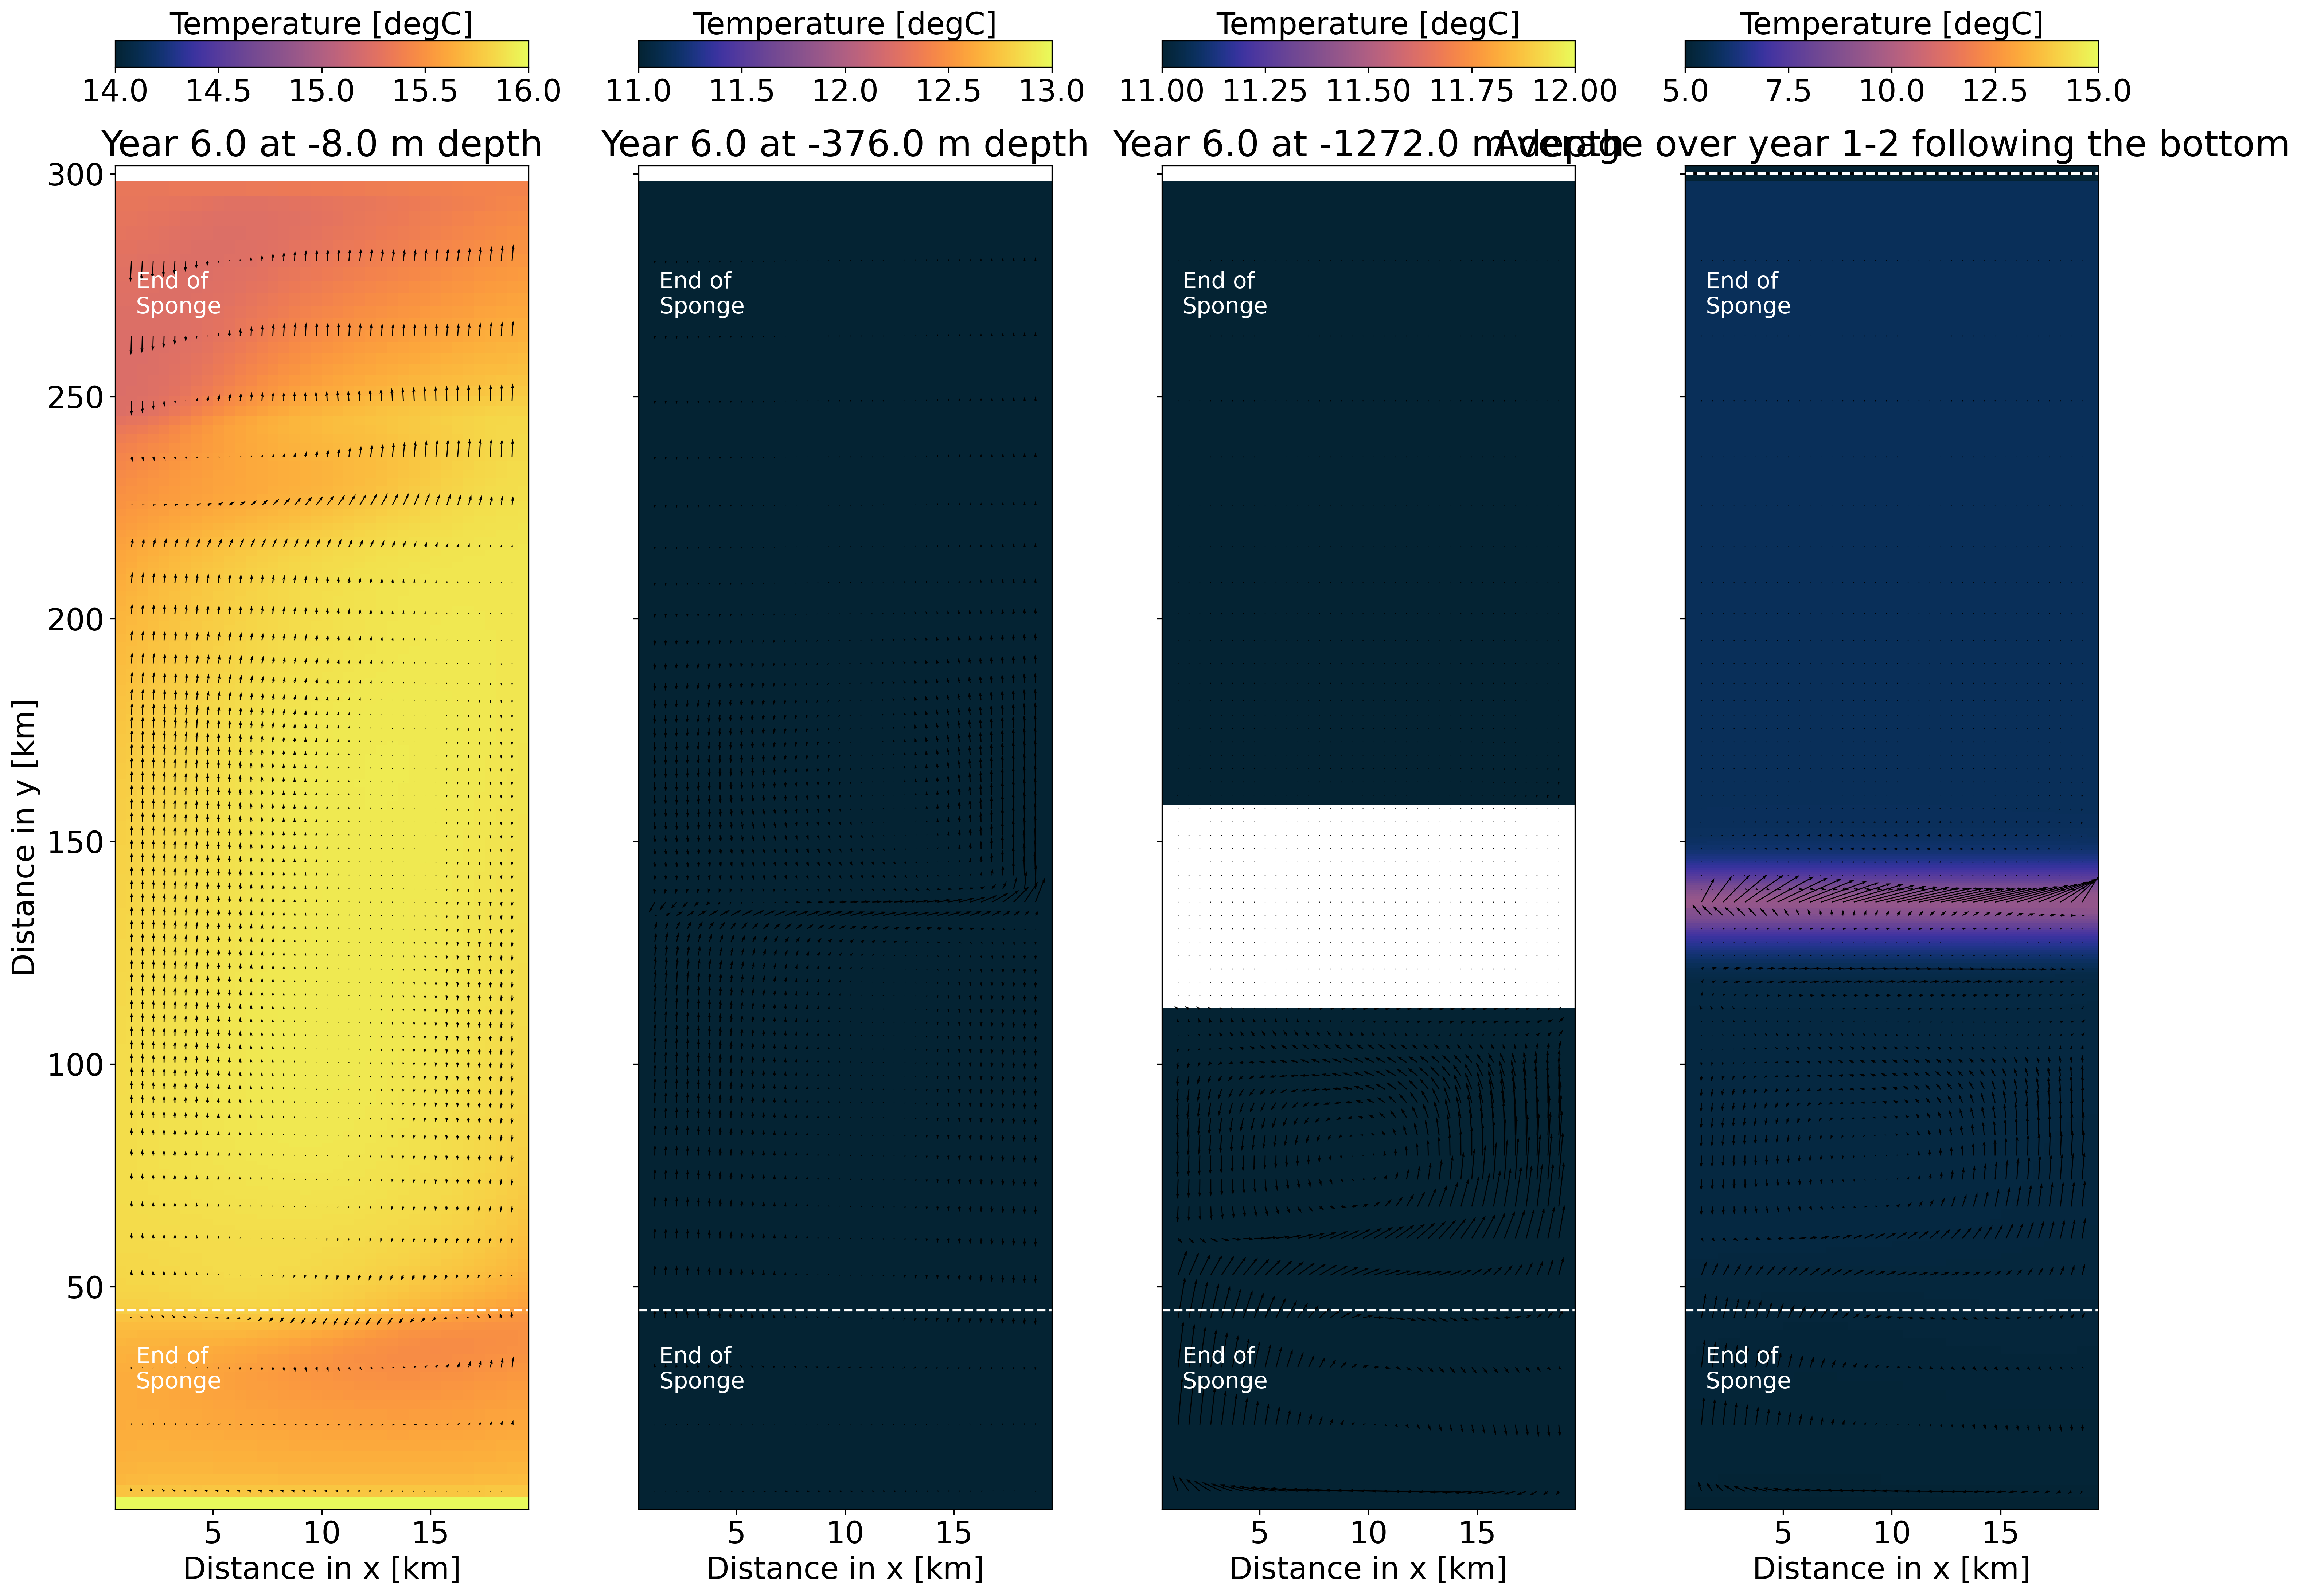

In [42]:
t=0
space=6
dep=[0,23,-1]
VARS=list(ds.keys())[:]


#for variable in VARS:

variable=VARS[2]

exec(f'varin=ds.{variable}')
title= 'Temperature [degC]'

Yin=dsG.Y
Xin=dsG.X[OBx:OBendx]

cmapi=cmocean.cm.thermal

fig,ax=plt.subplots(1,4)


tin=-1


axin=ax[0]
vmin=14 #np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
vmax=16 #-np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
axin.set(xlabel='Distance in x [km]',ylabel='Distance in y [km]')

timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin/1000, np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'Year {timein/360:.1f} at {dsG.Z[dep[0]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[1:-1].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1.values,dsG.X.values),ds.VVEL[tin,dep[0],:,:].values)
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y.values,dsG.Xp1.values),ds.UVEL[tin,dep[0],:,:].values)
U=interpU((gridY,gridX))

axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])

axin.axhline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
axin.text( 0.05, 0.09,'End of \nSponge', color='white', 
    transform=axin.transAxes,fontsize=15)
axin.axhline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
axin.text( 0.05,0.89, 'End of \nSponge', color='white', 
    transform=axin.transAxes,fontsize=15)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[1]

vmin=11 #np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
vmax=13 #-np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin/1000, np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'Year {timein/360:.1f} at {dsG.Z[dep[1]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[1:-1].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1.values,dsG.X.values),ds.VVEL[tin,dep[1],:,:].values)
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y.values,dsG.Xp1.values),ds.UVEL[tin,dep[1],:,:].values)
U=interpU((gridY,gridX))

axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])


axin.axhline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
axin.text( 0.05, 0.09,'End of \nSponge', color='white', 
    transform=axin.transAxes,fontsize=15)
axin.axhline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
axin.text( 0.05,0.89, 'End of \nSponge', color='white', 
    transform=axin.transAxes,fontsize=15)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[2]

vmin=11 #np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
vmax=12 # -np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin/1000, np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'Year {timein/360:.1f} at {dsG.Z[dep[2]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[1:-1].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1.values,dsG.X.values),ds.VVEL[tin,dep[2],:,:].values)
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y.values,dsG.Xp1.values),ds.UVEL[tin,dep[2],:,:].values)
U=interpU((gridY,gridX))

axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])


axin.axhline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
axin.text( 0.05, 0.09,'End of \nSponge', color='white', 
    transform=axin.transAxes,fontsize=15)
axin.axhline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
axin.text( 0.05,0.89, 'End of \nSponge', color='white', 
    transform=axin.transAxes,fontsize=15)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[3]

vmin= 5#np.min(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
vmax= 15#np.max(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')

indmean=23
timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin/1000, np.mean(tempOut[start:end,:,OBx:OBendx],axis=0),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.contour(Xin/1000, Yin/1000, np.mean(tempOut[start:end,:,OBx:OBendx],axis=0),levels=[0], colors='k')

gridY,gridX=np.meshgrid(Yin[1:-1].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1.values,dsG.X.values),np.mean(vvelOut[start:end,:,:],axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y.values,dsG.Xp1.values),np.mean(uvelOut[start:end,:,:],axis=0))
U=interpU((gridY,gridX))

axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])


axin.set(title=f'Average over year 1-2 following the bottom')

axin.axhline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
axin.text( 0.05, 0.09,'End of \nSponge', color='white', 
    transform=axin.transAxes,fontsize=15)
axin.axhline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
axin.text( 0.05,0.89, 'End of \nSponge', color='white', 
    transform=axin.transAxes,fontsize=15)

divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

fig.tight_layout()

fig.patch.set_alpha(0.0)
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'TempDifDepths.png', bbox_inches='tight')

In [10]:
params = {'font.size': 15,
          'figure.figsize': (5, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

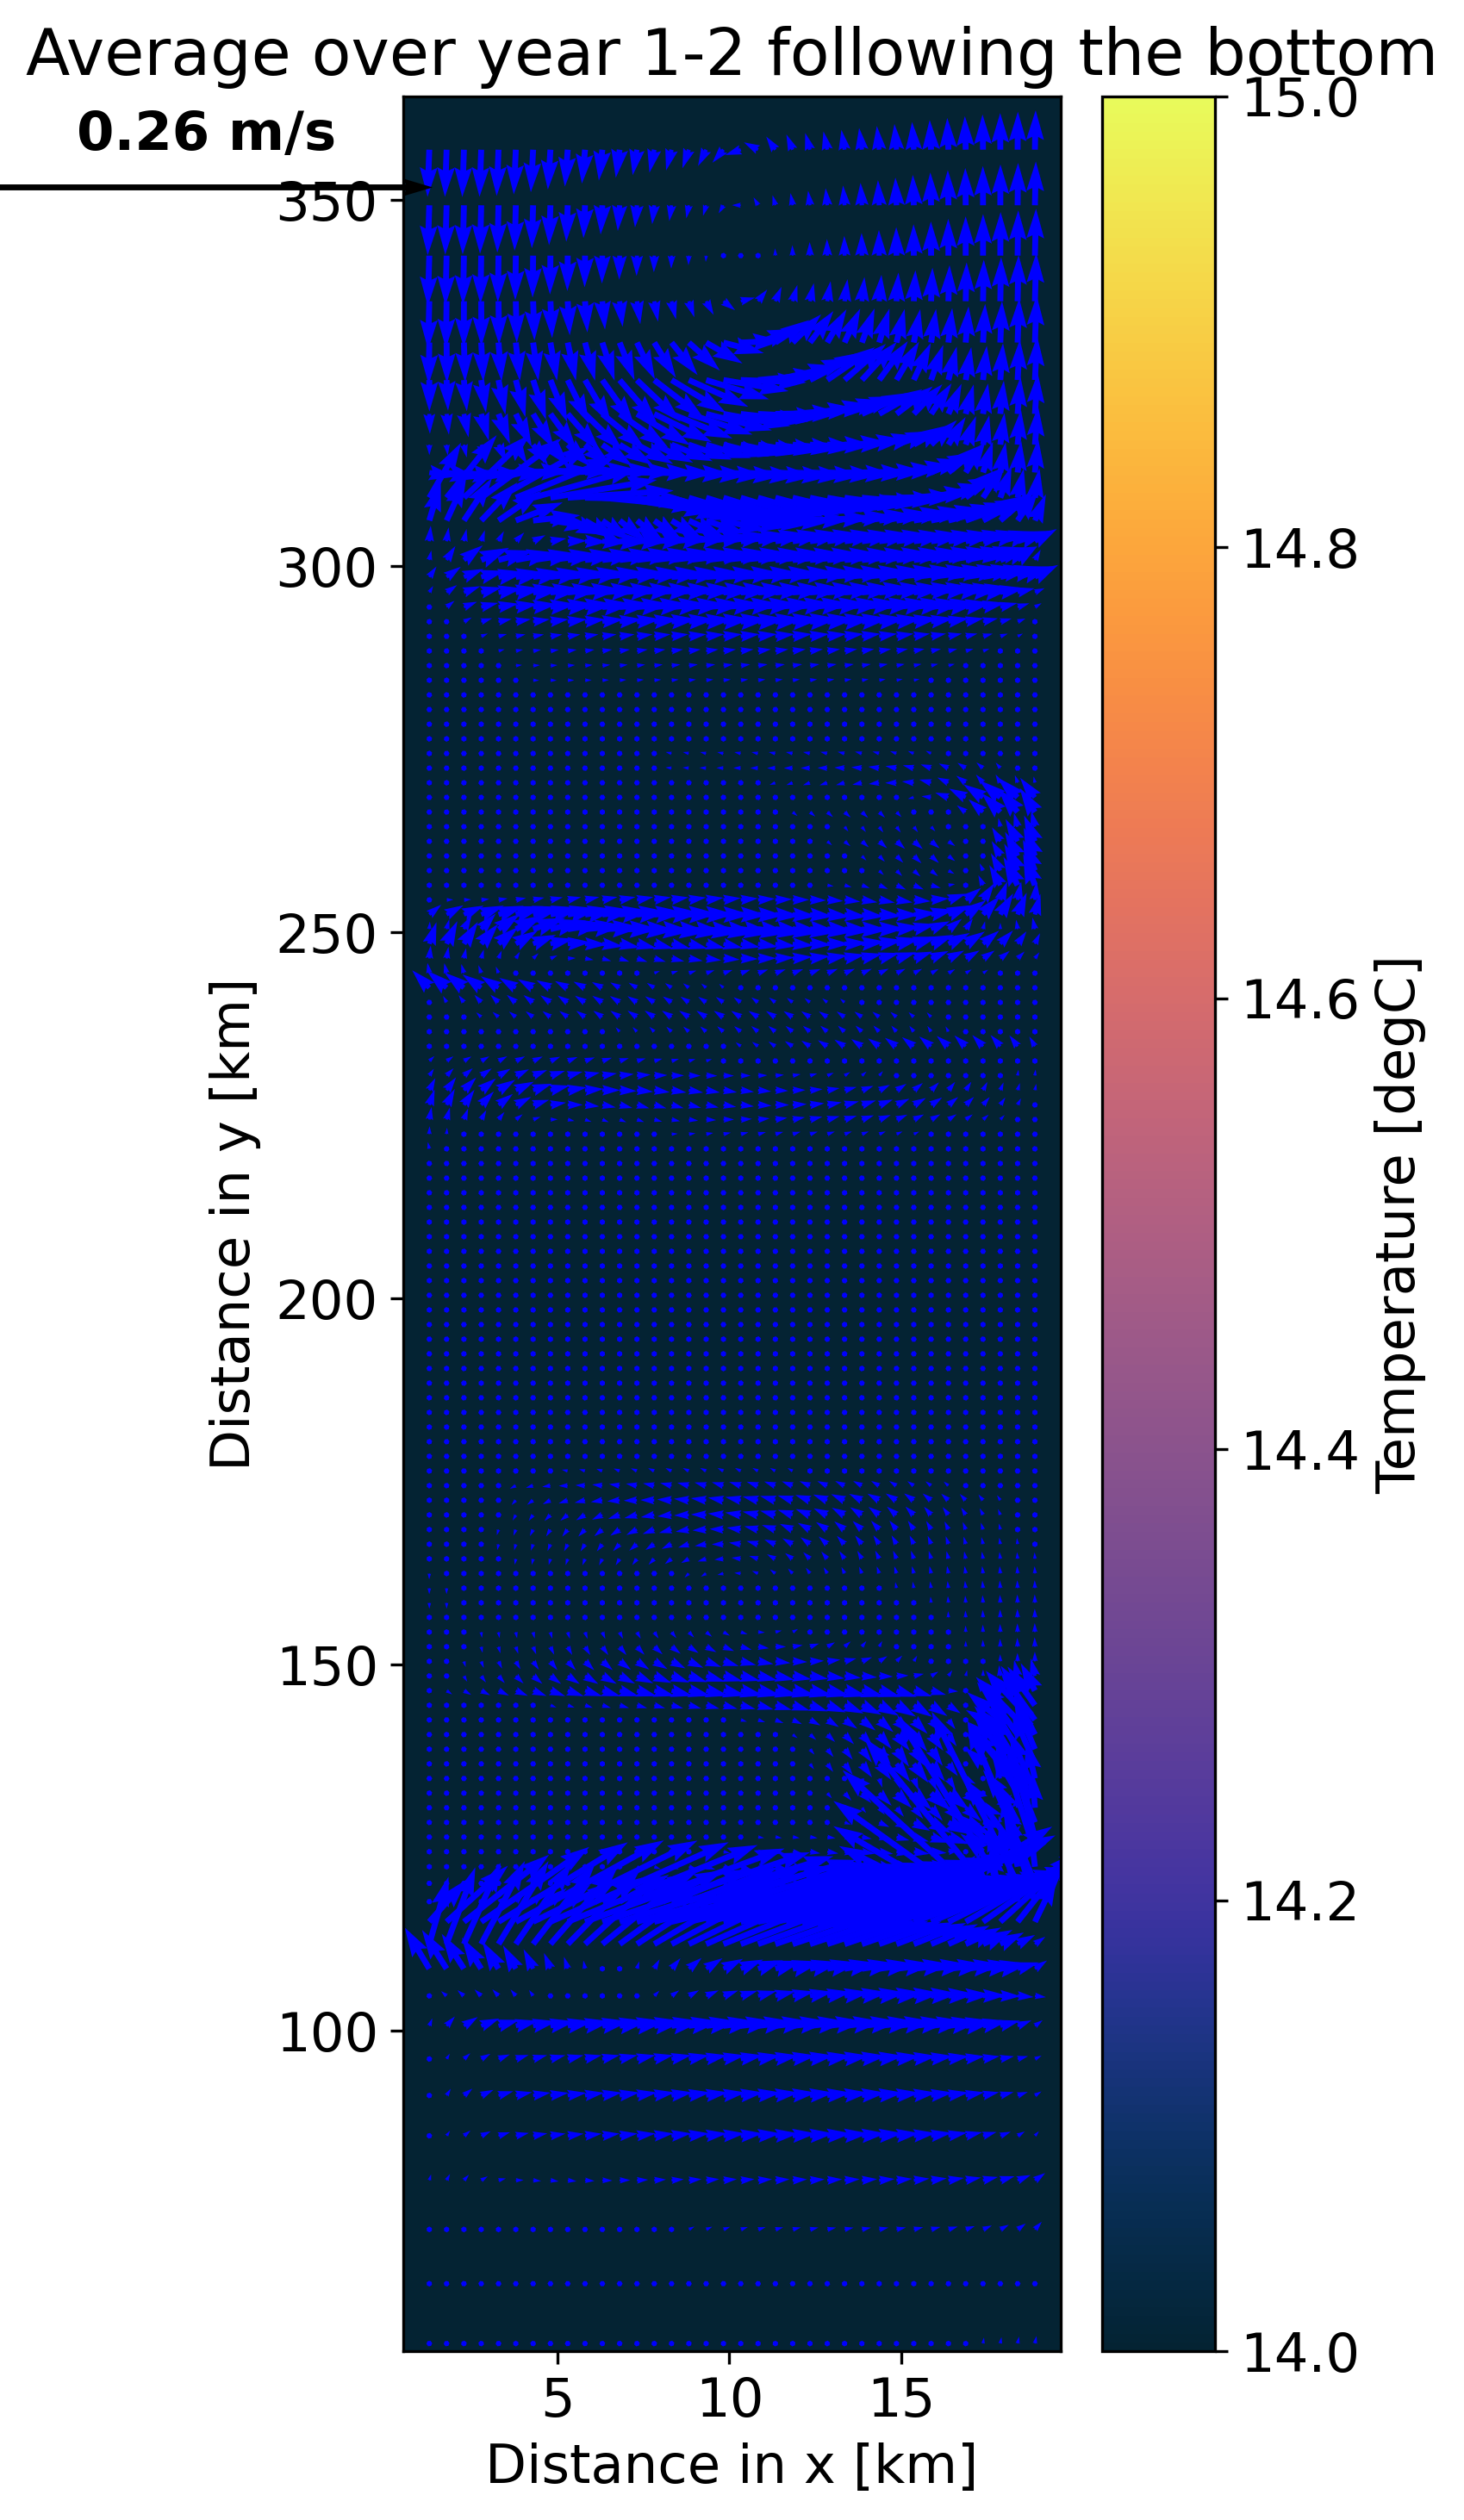

In [11]:
t=0
space=4
spacex=1
dep=[0,23,-1]
VARS=list(ds.keys())[:]


#for variable in VARS:

variable=VARS[2]

exec(f'varin=ds.{variable}')
title= 'Temperature [degC]'

Yin=dsG.Y
Xin=dsG.X[OBx:OBendx]

cmapi=cmocean.cm.thermal

fig,axin=plt.subplots()


tin=-1

vmin= 14#np.min(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
vmax= 15#np.max(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10


indmean=23
timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.mean(tempOut[start:end,OB:OBend,OBx:OBendx],axis=0),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.contour(Xin/1000, Yin[OB:OBend]/1000, np.mean(tempOut[start:end,OB:OBend,OBx:OBendx],axis=0),levels=[0], colors='k')

gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(vvelOut[start:end,OB:OBend,:],axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(uvelOut[start:end,OB:OBend,:],axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]
Q=axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:],color='blue',width=0.009,scale_units='xy', scale=0.02)



axin.quiverkey(Q, X=-0.3, Y=0.96, U=np.max(np.sqrt(Vind[np.arange(0,len(gridY[:,0]),spacex),:]**2+Uind[np.arange(0,len(gridY[:,0]),spacex),:]**2)), label=f'{np.max(np.sqrt(Vind[np.arange(0,len(gridY[:,0]),spacex),:]**2+Uind[np.arange(0,len(gridY[:,0]),spacex),:]**2)):.2f} m/s', coordinates='axes', fontproperties={'weight': 'bold'}, color='black')

axin.set(xlabel='Distance in x [km]',ylabel='Distance in y [km]')
axin.set(title=f'Average over year 1-2 following the bottom')




cbar_ax = plt.colorbar(cax)
cbar_ax.set_label(title)

fig.tight_layout()

fig.patch.set_alpha(0.0)
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'TempFollowBot.png', bbox_inches='tight')

In [10]:
params = {'font.size': 8,
          'figure.figsize': (10, 7.5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [11]:
sns.set_theme(context="talk",style='white')

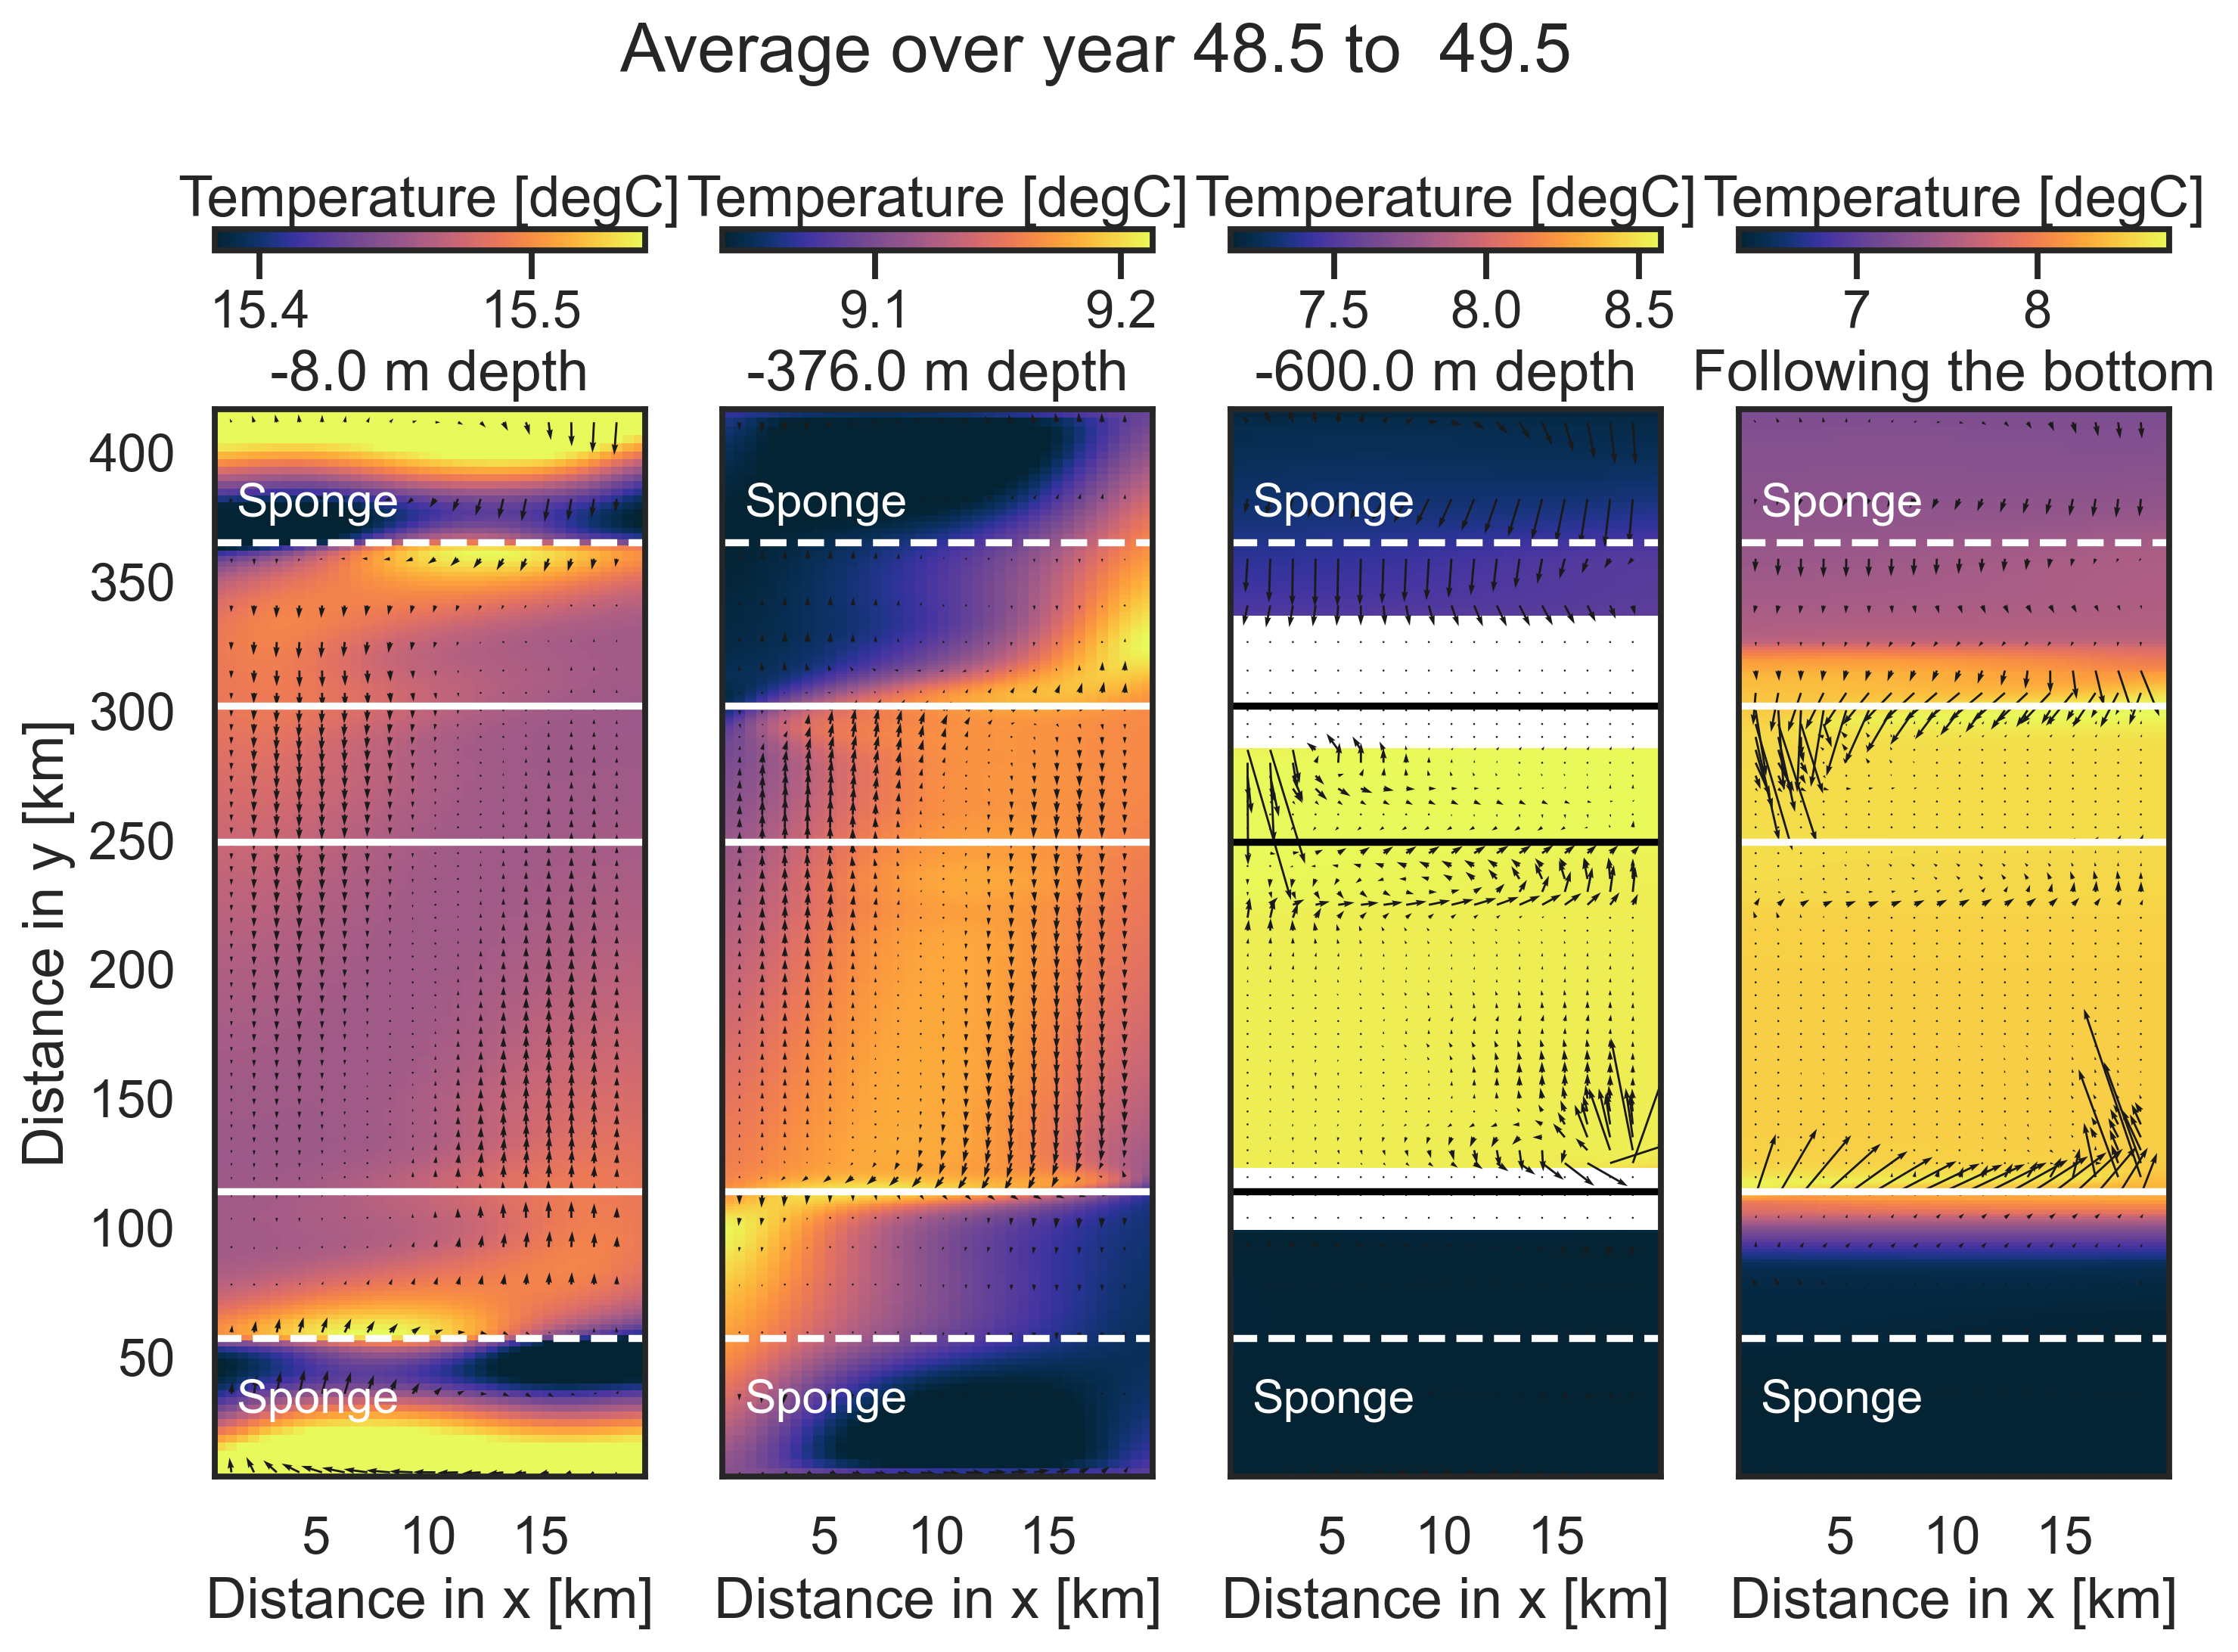

In [12]:
t=0
space=10
spacex=2
dep=[0,23,37]
VARS=list(ds.keys())[:]
widths = 0.005# np.linspace(0, 2, dsG.X[OBx:OBendx].values.size)

#for variable in VARS:


varin=ds.THETA
title= 'Temperature [degC]'

Yin=dsG.Y
Xin=dsG.X[OBx:OBendx]

cmapi=cmocean.cm.thermal

fig,ax=plt.subplots(1,4)


tin=np.arange(-4,-1,1)


axin=ax[0]
vmin=np.min(np.ma.masked_array(np.mean(varin[tin,dep[0],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[0],OB:OBend,OBx:OBendx])) #np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
vmax=np.max(np.ma.masked_array(np.mean(varin[tin,dep[0],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[0],OB:OBend,OBx:OBendx])) #-np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
levels=np.arange(vmin,vmax,0.1)
axin.set(xlabel='Distance in x [km]',ylabel='Distance in y [km]')

timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OBp:OBendp]/1000, np.ma.masked_array(np.mean(varin[tin,dep[0],OBp:OBendp,OBx:OBendx],axis=0),mask=mask[dep[0],OBp:OBendp,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[0]]:.1f} m depth')

#caxC=axin.contour(Xin/1000, Yin[OBp:OBendp]/1000, np.ma.masked_array(np.mean(varin[tin,dep[0],OBp:OBendp,OBx:OBendx],axis=0),mask=mask[dep[0],OBp:OBendp,OBx:OBendx]),levels=levels)
#axin.clabel(caxC, inline=1, fontsize='small')

gridY,gridX=np.meshgrid(Yin[OBp:OBendp].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OBp:OBendp].values,dsG.X.values),np.mean(dsVVEL.VVEL[tin,dep[0],OBp:OBendp,:],axis=0).values)
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OBp:OBendp].values,dsG.Xp1.values),np.mean(dsUVEL.UVEL[tin,dep[0],OBp:OBendp,:],axis=0).values)
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.7)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)


axin.axhline(dsG.Y[umbral1]/1000,c='white')
axin.axhline(dsG.Y[umbral2]/1000,c='white')
axin.axhline(dsG.Y[umbral3]/1000,c='white')

axin.axhline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
axin.text( 0.05, 0.06,'Sponge', color='white', 
    transform=axin.transAxes,fontsize='small')
if project == '2tracers' or project == 'realBathy':
    axin.axhline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text( 0.05,0.9, 'Sponge', color='white', 
        transform=axin.transAxes,fontsize='small')

axin=ax[1]

vmin=np.min(np.ma.masked_array(np.mean(varin[tin,dep[1],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[1],OB:OBend,OBx:OBendx])) #np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
vmax=np.max(np.ma.masked_array(np.mean(varin[tin,dep[1],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[1],OB:OBend,OBx:OBendx])) #-np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
levels=np.arange(vmin,vmax,0.02)
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OBp:OBendp]/1000, np.ma.masked_array(np.mean(varin[tin,dep[1],OBp:OBendp,OBx:OBendx],axis=0),mask=mask[dep[1],OBp:OBendp,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[1]]:.1f} m depth')

#caxC=axin.contour(Xin/1000, Yin[OBp:OBendp]/1000, np.ma.masked_array(np.mean(varin[tin,dep[1],OBp:OBendp,OBx:OBendx],axis=0),mask=mask[dep[1],OBp:OBendp,OBx:OBendx]),levels=levels)
#axin.clabel(caxC, inline=1, fontsize='small')



gridY,gridX=np.meshgrid(Yin[OBp:OBendp].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OBp:OBendp].values,dsG.X.values),np.mean(dsVVEL.VVEL[tin,dep[1],OBp:OBendp,:],axis=0).values)
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OBp:OBendp].values,dsG.Xp1.values),np.mean(dsUVEL.UVEL[tin,dep[1],OBp:OBendp,:],axis=0).values)
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.7)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin.axhline(dsG.Y[umbral1]/1000,c='white')
axin.axhline(dsG.Y[umbral2]/1000,c='white')
axin.axhline(dsG.Y[umbral3]/1000,c='white')

axin.axhline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
axin.text( 0.05, 0.06,'Sponge', color='white', 
    transform=axin.transAxes,fontsize='small')
if project == '2tracers' or project == 'realBathy':
    axin.axhline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text( 0.05,0.9, 'Sponge', color='white', 
        transform=axin.transAxes,fontsize='small')

axin=ax[2]

vmin=np.min(np.ma.masked_array(np.mean(varin[tin,dep[2],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[2],OB:OBend,OBx:OBendx])) #np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
vmax=np.max(np.ma.masked_array(np.mean(varin[tin,dep[2],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[2],OB:OBend,OBx:OBendx])) # -np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
levels=np.arange(vmin,vmax,0.01)
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OBp:OBendp]/1000, np.ma.masked_array(np.mean(varin[tin,dep[2],OBp:OBendp,OBx:OBendx],axis=0),mask=mask[dep[2],OBp:OBendp,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[2]]:.1f} m depth')

#caxC=axin.contour(Xin/1000, Yin[OBp:OBendp]/1000, np.ma.masked_array(np.mean(varin[tin,dep[2],OBp:OBendp,OBx:OBendx],axis=0),mask=mask[dep[2],OBp:OBendp,OBx:OBendx]),levels=levels)
#axin.clabel(caxC, inline=1, fontsize='small')

gridY,gridX=np.meshgrid(Yin[OBp:OBendp].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OBp:OBendp].values,dsG.X.values),np.mean(dsVVEL.VVEL[tin,dep[2],OBp:OBendp,:],axis=0).values)
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OBp:OBendp].values,dsG.Xp1.values),np.mean(dsUVEL.UVEL[tin,dep[2],OBp:OBendp,:],axis=0).values)
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.7)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin.axhline(dsG.Y[umbral1]/1000,c='black')
axin.axhline(dsG.Y[umbral2]/1000,c='black')
axin.axhline(dsG.Y[umbral3]/1000,c='black')

axin.axhline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
axin.text( 0.05, 0.06,'Sponge', color='white', 
    transform=axin.transAxes,fontsize='small')
if project == '2tracers' or project == 'realBathy':
    axin.axhline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text( 0.05,0.9, 'Sponge', color='white', 
        transform=axin.transAxes,fontsize='small')

axin=ax[3]

vmin= np.min(tempOut[tin,OB:OBend,OBx:OBendx]) #5.9#np.min(np.ma.masked_array(varin[start:,:,:,OBx:OBendx],mask=mask[:,:,OBx:OBendx]))/10
vmax= np.max(tempOut[tin,OB:OBend,OBx:OBendx]) #np.max(np.ma.masked_array(varin[start:,:,:,OBx:OBendx],mask=mask[:,:,OBx:OBendx]))/10
levels=np.arange(vmin,vmax,0.01)
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')

indmean=23
timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OBp:OBendp]/1000, np.mean(tempOut[tin,OBp:OBendp,OBx:OBendx],axis=0),vmin=vmin,vmax=vmax,cmap=cmapi)




gridY,gridX=np.meshgrid(Yin[OBp:OBendp].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OBp:OBendp].values,dsG.X.values),np.mean(vvelOut[tin,OBp:OBendp,:],axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OBp:OBendp].values,dsG.Xp1.values),np.mean(uvelOut[tin,OBp:OBendp,:],axis=0))
U=interpU((gridY,gridX))
gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:],width=widths)

axin.set(title=f'Following the bottom')

axin.axhline(dsG.Y[umbral1]/1000,c='white')
axin.axhline(dsG.Y[umbral2]/1000,c='white')
axin.axhline(dsG.Y[umbral3]/1000,c='white')

axin.axhline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
axin.text( 0.05, 0.06,'Sponge', color='white', 
    transform=axin.transAxes,fontsize='small')
if project == '2tracers' or project == 'realBathy':
    axin.axhline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text( 0.05,0.9, 'Sponge', color='white', 
        transform=axin.transAxes,fontsize='small')

divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.7)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

fig.suptitle(f'Average over year {ds.T[tin[0]].values/(3600*24*360)} to  {ds.T[tin[-1]].values/(3600*24*360)}')

fig.tight_layout()

fig.patch.set_alpha(0.0)
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'TempDifDepthsPresentation.png', bbox_inches='tight')